In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# MODÜLER ÜS ALMA FONKSİYONU 
def c_amod15(a, power):
    """a^power mod 15 işlemini yapan kontrollü kapı"""
    if a not in [2,7,8,11,13]:
        raise ValueError("'a' değeri 2,7,8,11 veya 13 olmalıdır")
    
    U = QuantumCircuit(4)        
    for _ in range(power):
        if a in [2,13]:
            U.swap(0,1); U.swap(1,2); U.swap(2,3)
        if a in [7,8]:
            U.swap(2,3); U.swap(1,2); U.swap(0,1)
        if a == 11:
            U.swap(1,3); U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    return U.control()

In [3]:
n_count = 8  # Sayma kübiti sayısı (Hassasiyet)
a = 7        # Seçilen sayı

C:\Users\umran\AppData\Local\Temp\ipykernel_39412\1623054388.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(num_qubits=n_count, inverse=True).to_gate(), range(n_count))


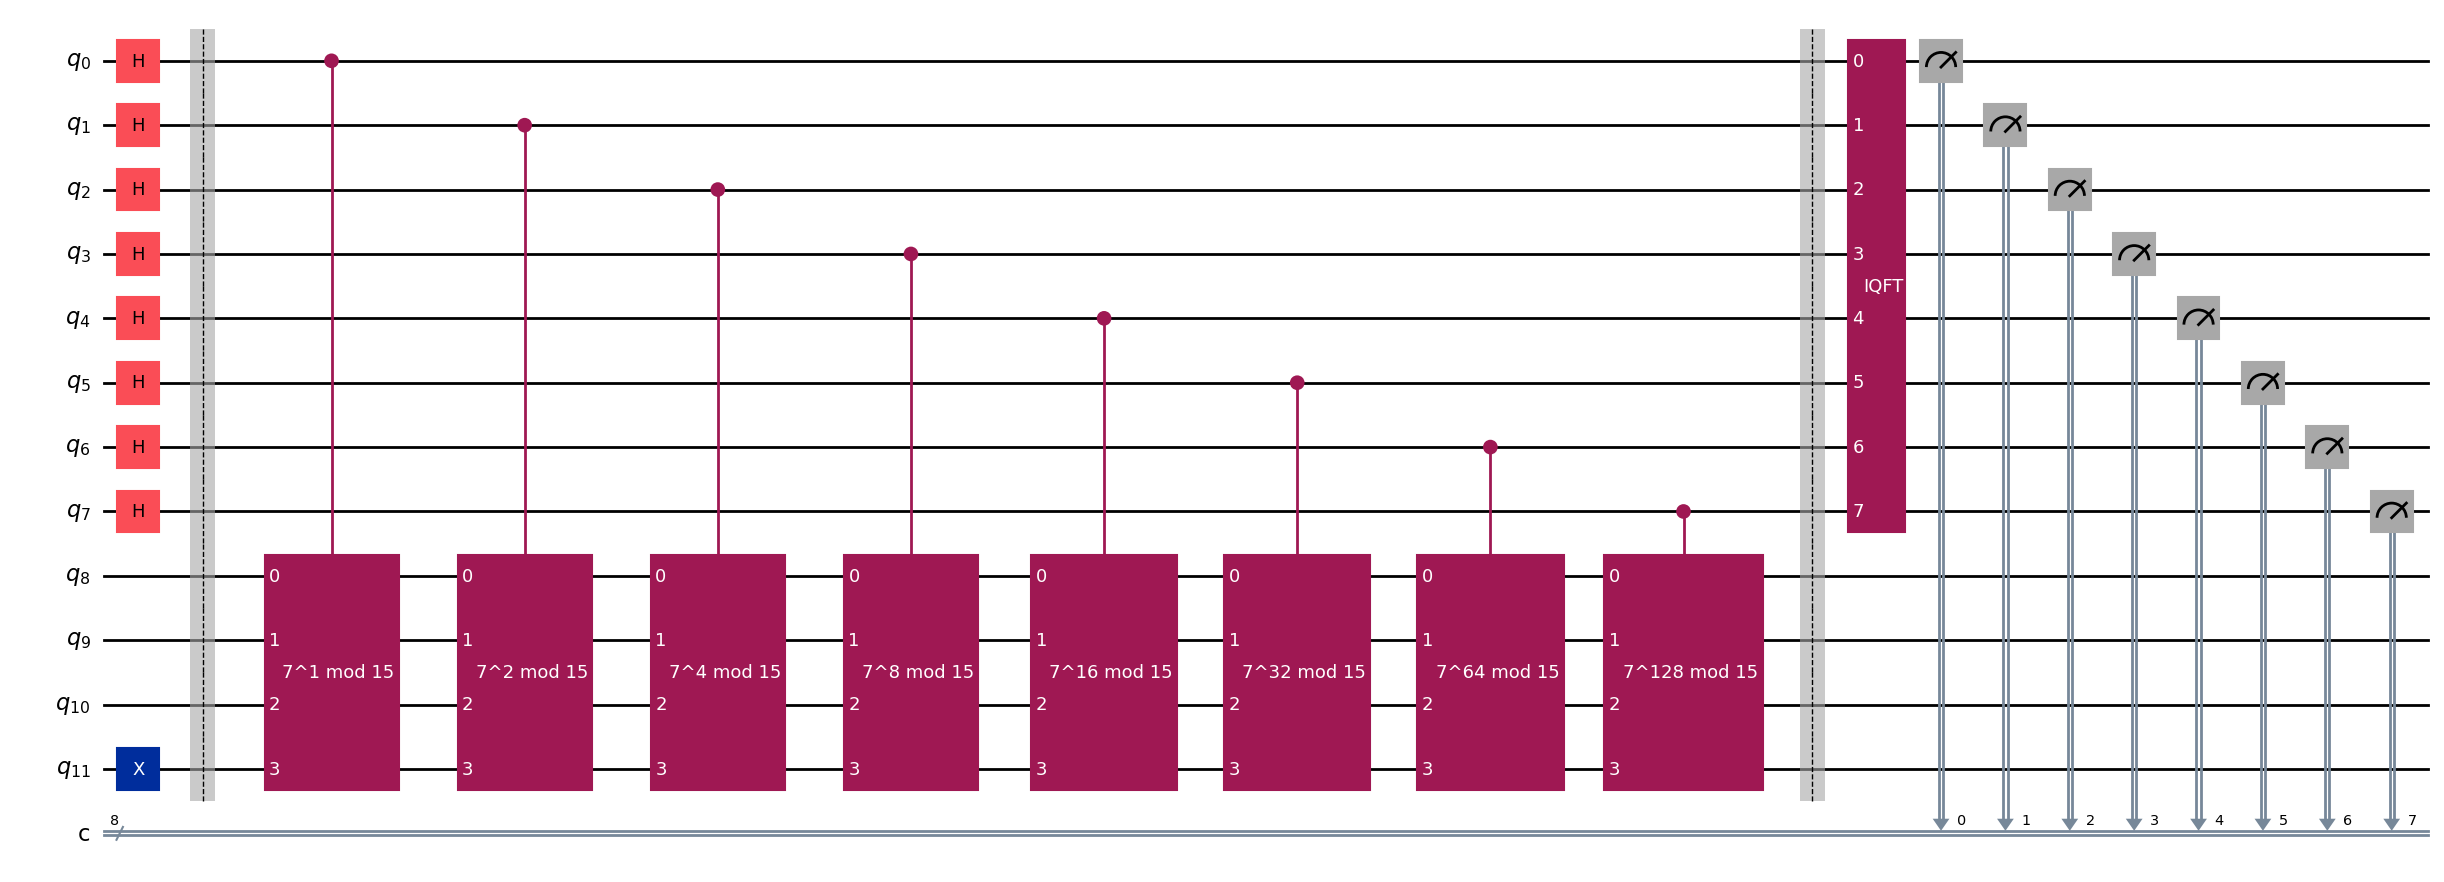

In [4]:
qc = QuantumCircuit(n_count + 4, n_count)

# Sayma kübitlerini süperpozisyona sok (|+) durumu)
qc.h(range(n_count))

# Yardımcı register'ı |1> durumuna getir
qc.x(n_count + 3) 

qc.barrier()

# Kontrollü-U işlemlerini uygula
for q in range(n_count):
    qc.append(c_amod15(a, 2**q), [q] + [i+n_count for i in range(4)])

qc.barrier()

# Ters QFT (Daha modern ve hatasız yöntem)
# cu1 hatası almamak için hazır QFT kütüphanesini kullanıyoruz
qc.append(QFT(num_qubits=n_count, inverse=True).to_gate(), range(n_count))

qc.measure(range(n_count), range(n_count))

display(qc.draw(output='mpl', fold=-1))

In [5]:
simulator = AerSimulator()
t_qc = transpile(qc, simulator)
counts = simulator.run(t_qc, shots=1024).result().get_counts()

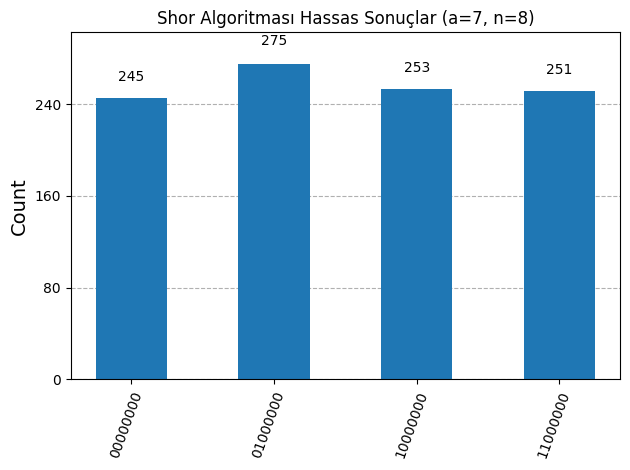

In [6]:
display(plot_histogram(counts, title=f"Shor Algoritması Hassas Sonuçlar (a={a}, n={n_count})"))